# Persiapan

In [29]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as npy # linear algebra
import pandas as pds # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator as ImgDataGen

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory


In [30]:
# Specify important directories
import os, sys, time, warnings, sklearn
ROOT='/kaggle/input'
# ROOT='data'
TEST_PATH= "/kaggle/input/datasets/ananthu017/emotion-detection-fer/test"
TRAIN_PATH='/kaggle/input/datasets/ananthu017/emotion-detection-fer/train'

train_angry_img_path=TRAIN_PATH +'/angry'

OVERSAMPLED_TRAIN_PATH='fed_oversampled_train'
MODEL_PATH='models'
IMAGE_PATH='images'

# EDA

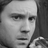

In [31]:
# Load a sample image 
# using open() to open images
image_data = Image.open(train_angry_img_path+'/im0.png')
image_data

Image shape: (48, 48)
Image data array: [[ 70  80  82 ...  52  43  41]
 [ 65  61  58 ...  56  52  44]
 [ 50  43  54 ...  49  56  47]
 ...
 [ 91  65  42 ...  72  56  43]
 [ 77  82  79 ... 105  70  46]
 [ 77  72  84 ... 106 109  82]]
Image array shape: (48, 48)


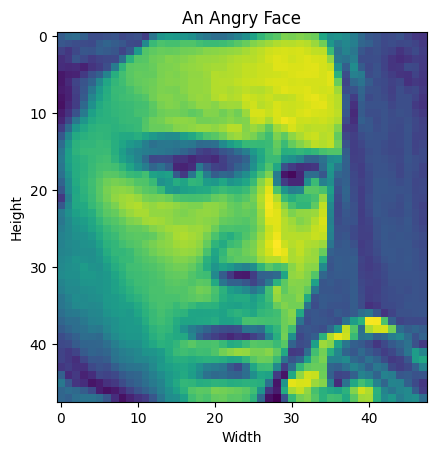

In [32]:
# Get the shape of the image
image=plt.imread(train_angry_img_path+'/im0.png')
print(f'Image shape: {image.shape}')

# Convert image data (like jpeg) to numpy using asarray()
image_array = npy.asarray(image_data)
print(f'Image data array: {image_array}')

# Get the shape of the image array
print(f'Image array shape: {image_array.shape}')

# Printing the image 
plt.imshow(image_array)
plt.xlabel('Width')
plt.ylabel('Height')
plt.title('An Angry Face')
plt.show()

In [33]:
# Get the list of folders in the directory as classes
classes=os.listdir(TRAIN_PATH+'/')
classes

['fearful', 'disgusted', 'angry', 'neutral', 'sad', 'surprised', 'happy']

In [34]:
# Get dictionary list of image count per class
def class_sample(type):
    if type.lower() == 'test' or type.lower() == 'train':
        path=''
        if type.lower() == 'train':    
            path= TRAIN_PATH
        else:
            path= TEST_PATH
        
        filepath=path+'/'
        class_count = []
        class_dict ={}
        for folder in os.listdir(filepath) :
              class_count.append(len(os.listdir(filepath+folder)))
              class_dict[folder]=len(os.listdir(filepath+folder))
        class_total = sum(class_count)
        return class_total, class_count, class_dict
    else:
        raise ValueError('Invalid type. Must be "test" or "train".')


def test_train_distribution():
      print("---- Train Set ----")
      avg_train=class_sample('train')[0]/len(class_sample('train')[1])
      print(f'Train class distribution:\n{class_sample("train")[2]}')
      print("Average train class: ",round(avg_train))    
      print('Total train: ', class_sample('train')[0])

      print("\n---- Test Set ----")
      avg_test=class_sample('test')[0]/len(class_sample('test')[1])
      print(f'Test class distribution:\n{class_sample("test")[2]}')
      print("Average test class: ",round(avg_test)) 
      print('Total test: ', class_sample('test')[0])


test_train_distribution()

---- Train Set ----
Train class distribution:
{'fearful': 4097, 'disgusted': 436, 'angry': 3995, 'neutral': 4965, 'sad': 4830, 'surprised': 3171, 'happy': 7215}
Average train class:  4101
Total train:  28709

---- Test Set ----
Test class distribution:
{'fearful': 1024, 'disgusted': 111, 'angry': 958, 'neutral': 1233, 'sad': 1247, 'surprised': 831, 'happy': 1774}
Average test class:  1025
Total test:  7178


# Data Preprocessing

## Data Augmentation

In [35]:
target_size=(48, 48)
# target_size=(224, 224)
batch_size=32

## Train Image Data Generator instance. 
# We will not apply any transformon specific orientations or features and no initial rescale to the image
# We'll only split the image data into train and validation set
trainValidation_data_generator = ImgDataGen(
                                    rescale=1./255,  # Gunakan 255, bukan 225
                                    rotation_range=10,
                                    zoom_range=0.2,
                                    width_shift_range=0.1,
                                    height_shift_range=0.1,
                                    shear_range=0.2,
                                    horizontal_flip=True,
                                    fill_mode='nearest',
                                    validation_split=0.2
)


# Test Image Data Generator instance for Test data
test_data_generator = ImgDataGen(
                                rescale = 1./255,
                                )


# Data Generator

In [36]:
## Mapping images to their classes.
print('Train Set Generated - ',end=' ') 
train_generator = trainValidation_data_generator.flow_from_directory( 
                                                            directory=TRAIN_PATH, 
                                                            target_size=target_size,
                                                            batch_size=batch_size,
                                                            class_mode='categorical', 
                                                            color_mode='rgb', 
                                                            classes=classes,
                                                            shuffle=True, 
                                                            subset='training' # set as training data
                                                        )
## Mapping images to their classes.
print('Validation Set Generated - ',end=' ') 
validation_generator = trainValidation_data_generator.flow_from_directory(
                                                            directory=TRAIN_PATH, 
                                                            target_size=target_size,
                                                            batch_size=batch_size,
                                                            class_mode='categorical', 
                                                            color_mode='rgb', 
                                                            classes= classes,
                                                            shuffle=False, 
                                                            subset='validation' # set as validation data
                                                        )
test_samples=class_sample('test')[0]
test_batch_size=batch_size
test_steps=int(test_samples/test_batch_size)

## Mapping images to their classes.
print('Test Set Generated - ',end=' ') 
test_generator = test_data_generator.flow_from_directory(
                                        directory=TEST_PATH, 
                                        target_size=target_size,
                                        class_mode='categorical', 
                                        color_mode='rgb', 
                                        classes=classes,
                                        shuffle=False, 
                                        batch_size=test_batch_size
                                        )

## Mapping shuffled images to their classes.
print('Shuffled Test Set Generated - ',end=' ') 
test_generator_shuffled = test_data_generator.flow_from_directory(
                                        TEST_PATH, 
                                        target_size=target_size,
                                        class_mode='categorical', 
                                        color_mode='rgb', 
                                        classes=classes,
                                        shuffle=True, 
                                        batch_size=test_batch_size
                                        )

Train Set Generated -  Found 22968 images belonging to 7 classes.
Validation Set Generated -  Found 5741 images belonging to 7 classes.
Test Set Generated -  Found 7178 images belonging to 7 classes.
Shuffled Test Set Generated -  Found 7178 images belonging to 7 classes.


In [37]:
# From the generator we can get information we will need later
# classes=  # os.listdir(TRAIN_PATH+'/')
class_dictionary = train_generator.class_indices
class_keys = list(train_generator.class_indices.keys())
class_values = list(train_generator.class_indices.values())
class_count = len(class_keys)

print ('test batch size: ' ,test_batch_size, '  test steps: ', test_steps, ' number of classes : ', class_count)

train_images, train_labels = next(train_generator)
validation_images, validation_labels = next(validation_generator)
test_images, test_labels = next(test_generator)

print(f'\nThere are 7 classes: {classes}')
print(f'The class dictionary are: {class_dictionary}')
print('Class count: ', class_count)

print('\nX_train shape: ', train_images.shape)
print('y_train shape: ', train_labels.shape)
print('\nX_test shape: ', test_images.shape)
print('y_test shape: ', test_labels.shape)

print('\ntrain_generator sample: ', train_generator.samples)
print('validation_generator sample: ', validation_generator.samples)
print('test_generator sample: ', test_generator.samples)

print('\ntrain_generator sample: ', train_generator.labels)
print('validation_generator sample: ', validation_generator.labels)
print('test_generator sample: ', test_generator.labels)

test batch size:  32   test steps:  224  number of classes :  7

There are 7 classes: ['fearful', 'disgusted', 'angry', 'neutral', 'sad', 'surprised', 'happy']
The class dictionary are: {'fearful': 0, 'disgusted': 1, 'angry': 2, 'neutral': 3, 'sad': 4, 'surprised': 5, 'happy': 6}
Class count:  7

X_train shape:  (32, 48, 48, 3)
y_train shape:  (32, 7)

X_test shape:  (32, 48, 48, 3)
y_test shape:  (32, 7)

train_generator sample:  22968
validation_generator sample:  5741
test_generator sample:  7178

train_generator sample:  [0 0 0 ... 6 6 6]
validation_generator sample:  [0 0 0 ... 6 6 6]
test_generator sample:  [0 0 0 ... 6 6 6]


In [38]:
class_indices = train_generator.class_indices
class_counts = {class_name: 0 for class_name in class_indices}
num_images = train_generator.samples

batch_size = train_generator.batch_size
num_batches = len(train_generator)

for i in range(num_batches):
    batch = next(train_generator)
    images, labels = batch
    for j in range(len(labels)):
        label = npy.argmax(labels[j])  # convert one-hot encoding to integer label
        class_name = list(class_indices.keys())[list(class_indices.values()).index(label)]
        class_counts[class_name] += 1

print(class_counts)
print(f"Total number of images in train generator: {num_images}")

{'fearful': 3273, 'disgusted': 348, 'angry': 3198, 'neutral': 3967, 'sad': 3867, 'surprised': 2540, 'happy': 5775}
Total number of images in train generator: 22968


# Visual

In [39]:
import numpy as np

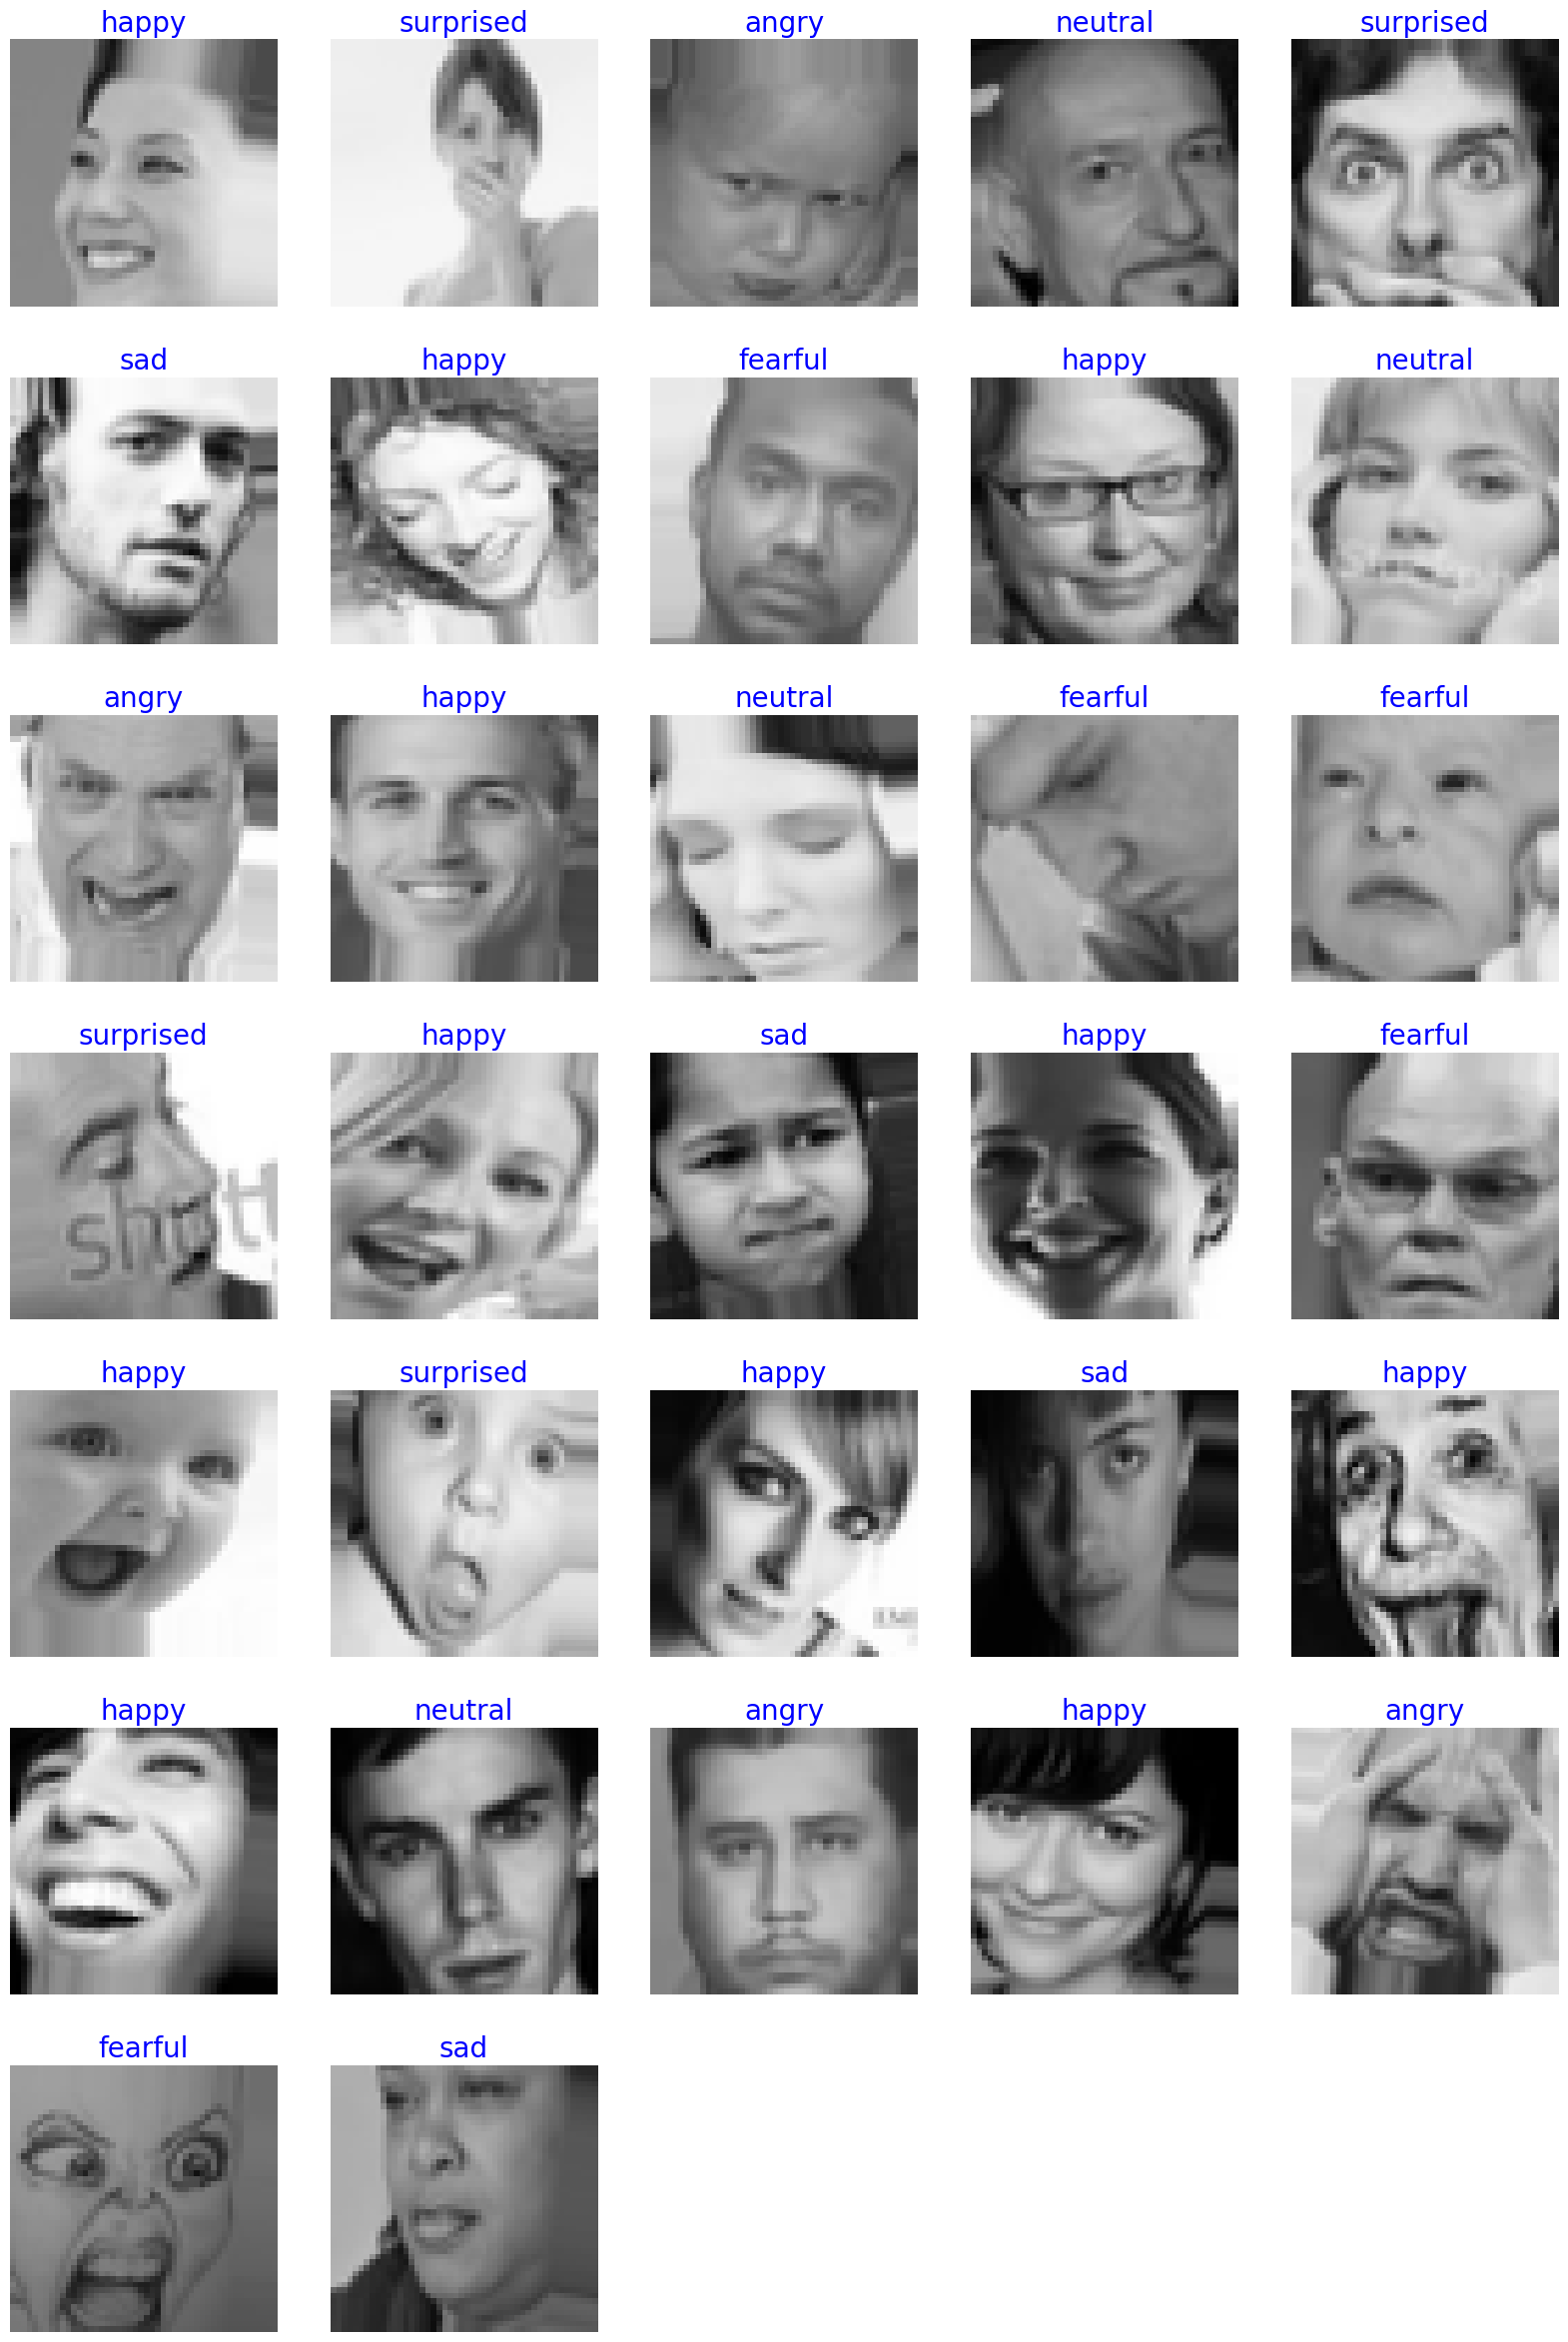

In [40]:
# Get the sample images, labels, and their filenames 
# To get the correct filename, turn off the shuffle
def plotImageWithNames(gen):
    images, labels = next(gen)
    classes = list(gen.class_indices.keys())
    
    plt.figure(figsize=(20, 30))
    length = len(labels)
    r = min(length, 32) # Menggunakan min() lebih simpel daripada if-else
    
    for i in range(r):        
        plt.subplot(7, 5, i + 1)
        
        # PERBAIKAN: Gunakan image langsung tanpa dibagi 255 lagi
        # karena generator sudah melakukan rescaling
        image = images[i] 
        
        # Jika gambar terlihat terlalu gelap/aneh karena floating point, 
        # kamu bisa memastikan nilainya klip di rentang 0-1
        image = np.clip(image, 0, 1)
        
        plt.imshow(image)
        
        index = np.argmax(labels[i])
        class_name = classes[index]
        
        plt.title(
            label=f"{class_name}", 
            color='blue', 
            fontsize=20
        )
        plt.axis('off')
    plt.show()

plotImageWithNames(train_generator)

# PSO

In [41]:
# pip install pyswarms

In [42]:
# import pyswarms as ps
# import tensorflow.keras.backend as K
# import gc
# import tensorflow as tf
# from tensorflow.keras import layers, models
# import numpy as np

# img_height = 48
# img_width = 48 

# def fitness_function(params):
#     results = []
    
#     for p in params:
#         # Ekstraksi parameter dari partikel PSO
#         lr = p[0]
#         f1 = int(p[1])   # Jumlah filter Block 1
#         f2 = int(p[2])   # Jumlah filter Block 2
#         f3 = int(p[3])   # Jumlah filter Block 3
#         dense_u = int(p[4]) # Jumlah neuron Dense layer
        
#         # Build model berdasarkan partikel
#         model = models.Sequential([
#             layers.Input(shape=(img_height, img_width, 3)),
            
#             # Block 1
#             layers.Conv2D(f1, (3, 3), activation='relu', padding='same'),
#             layers.BatchNormalization(),
#             layers.Conv2D(f1*2, (3, 3), activation='relu', padding='same'),
#             layers.BatchNormalization(),
#             layers.MaxPooling2D((2, 2)),
#             layers.Dropout(0.25),

#             # Block 2
#             layers.Conv2D(f2, (3, 3), activation='relu', padding='same'),
#             layers.BatchNormalization(),
#             layers.MaxPooling2D((2, 2)),
#             layers.Dropout(0.25),

#             # Block 3
#             layers.Conv2D(f3, (3, 3), activation='relu', padding='same'),
#             layers.BatchNormalization(),
#             layers.MaxPooling2D((2, 2)),
#             layers.Dropout(0.25),

#             layers.Flatten(),
#             layers.Dense(dense_u, activation='relu'),
#             layers.BatchNormalization(),
#             layers.Dropout(0.5),
#             layers.Dense(len(classes), activation='softmax')
#         ])
        
#         model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
#                       loss='categorical_crossentropy',
#                       metrics=['accuracy'])
        
#         # Evaluasi cepat (Fitness function)
#         # Gunakan epoch sedikit (misal 3-5) agar pencarian PSO tidak terlalu lama
#         history = model.fit(train_generator, epochs=5, 
#                             validation_data=validation_generator, 
#                             verbose=0)
        
#         # Kita ingin memaksimalkan akurasi, jadi perkecil (1 - akurasi)
#         val_acc = max(history.history['val_accuracy'])
#         results.append(1 - val_acc)
        
#         # TAMBAHKAN INI agar memori tidak penuh:
#         K.clear_session()
#         del model
#         gc.collect()
        
#     return np.array(results)

In [43]:
# # Batas Pencarian: [LR, F1, F2, F3, Dense]
# # Sesuaikan jumlah elemen dengan dimensions=5
# lb = [1e-3, 16, 64, 128, 128]   # Tambahkan batas bawah untuk F3
# ub = [1e-2, 64, 256, 512, 1024] # Tambahkan batas atas untuk F3

# # Jalankan Optimizer
# # Pastikan dimensions=5 sesuai dengan jumlah elemen di lb dan ub
# optimizer = ps.single.GlobalBestPSO(n_particles=10, 
#                                     dimensions=5, 
#                                     options={'c1': 0.5, 'c2': 0.3, 'w': 0.9}, 
#                                     bounds=(lb, ub))

# best_cost, best_pos = optimizer.optimize(fitness_function, iters=5)

In [44]:
# print(f"""
# === Hasil Optimasi PSO ===
# Learning Rate : {best_pos[0]:.6f}
# Filter 1      : {int(best_pos[1])}
# Filter 2      : {int(best_pos[2])}
# Filter 3      : {int(best_pos[3])}
# Dense Units   : {int(best_pos[4])}
# """)

# Modeling

In [45]:
# lr_best = (best_pos[0])
# f1 = int(best_pos[1])
# f2 = int(best_pos[2])
# f3 = int(best_pos[3])
# dense_u = int(best_pos[4])

In [46]:
lr_best = 0.001128
f1 = 51
f2 = 114
f3 = 474
dense_u = 192

In [47]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow import keras

# 1. Gunakan nilai hasil PSO langsung ke dalam Adam Optimizer
# Ganti 'lr_best' dengan variabel nilai dari PSO kamu
optimizer_pso = Adam(learning_rate=lr_best) 

# 2. Checkpoint: Cukup simpan model terbaik berdasarkan val_accuracy
checkpoint = ModelCheckpoint(
    'best_model' + model_name + '.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# 3. Hapus ReduceLROnPlateau dari daftar callback agar LR tetap FIXED
callbacks_list = [checkpoint]

In [48]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Asumsi target_size yang kamu gunakan (misal: 48 atau 64)
# Sesuaikan dengan variabel target_size di kode kamu
img_height = 48
img_width = 48 

def build_final_model():
    model = models.Sequential([
        layers.Input(shape=(img_height, img_width, 3)),
        
        # Block 1
        layers.Conv2D(f1, (3, 3), activation='relu', padding='same', input_shape=(img_height, img_width, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(f1*2, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(f2, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(f3, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Full Connected
        layers.Flatten(),
        layers.Dense(dense_u, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(len(classes), activation='softmax') # Mengikuti jumlah class kamu
    ])
    
    return model

model = build_final_model()
model.compile(
    optimizer=optimizer_pso, 
    loss='categorical_crossentropy', # Sesuaikan dengan loss function kamu
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [49]:
# Model Architecture path
def model_arch(model_name):
    # !mkdir -p images
    !mkdir images
    arch=IMAGE_PATH+'/fer-2013_'+model_name+'.png'
    return arch

#  TensorFlow Checkpoint save_weight uses .ckpt extension format
def checkpoint_path(model_name):
    # !mkdir models
    checkpoint_path = MODEL_PATH+"/fedav_best_model-"+model_name+".ckpt"
    return checkpoint_path

model_name = "CNN_POS_5_withoutOversampling"

In [50]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 51)     │         1,428 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 48, 48, 51)     │           204 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 48, 48, 102)    │        46,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 48, 48, 102)    │           408 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 102)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 24, 102)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 114)    │       104,766 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 24, 24, 114)    │           456 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 114)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 12, 12, 114)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 474)    │       486,798 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 12, 474)    │         1,896 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 474)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 6, 6, 474)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 17064)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 192)            │     3,276,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 192)            │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,351 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,921,475 (14.96 MB)

 Trainable params: 3,919,609 (14.95 MB)

 Non-trainable params: 1,866 (7.29 KB)

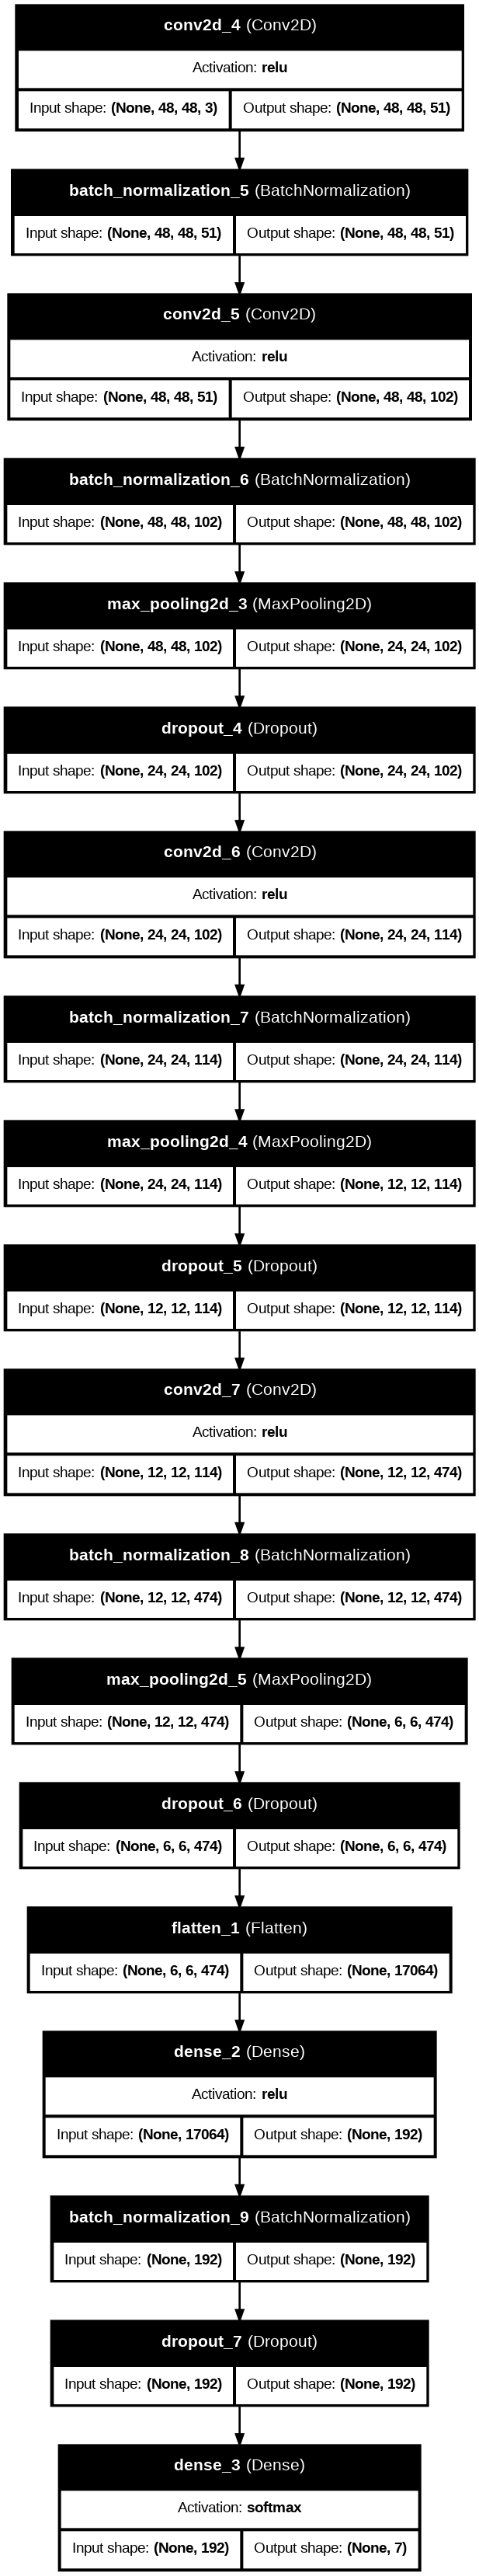

In [51]:
from tensorflow.keras.utils import plot_model

# Pastikan model sudah dibangun (misal: model = build_final_model())
plot_model(
    model,
    to_file='arsitektur_model_'+model_name+'.png', # Nama file yang akan disimpan
    show_shapes=True,                    # Menampilkan ukuran input/output (sangat membantu!)
    show_layer_names=True,               # Menampilkan nama layer
    show_layer_activations=True,         # Menampilkan fungsi aktivasi (ReLU, Softmax, dll)
    dpi=96                               # Kualitas gambar
)

In [52]:
# Pastikan callback ASK yang sudah diperbaiki atau checkpoint digunakan di sini
history = model.fit(
    train_generator,
    epochs=50, # Sesuaikan
    validation_data=validation_generator,
    callbacks=callbacks_list # Gunakan checkpoint agar model langsung tersimpan saat training
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1778642762.315164     136 service.cc:152] XLA service 0x7ef788008380 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778642762.315254     136 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778642762.996324     136 cuda_dnn.cc:529] Loaded cuDNN version 91002


  4/718 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.1419 - loss: 3.2810 

I0000 00:00:1778642769.568596     136 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.2276 - loss: 2.2572
Epoch 1: val_accuracy improved from -inf to 0.31127, saving model to best_modelCNN_POS_5_withoutOversampling.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 101s 125ms/step - accuracy: 0.2277 - loss: 2.2568 - val_accuracy: 0.3113 - val_loss: 1.7439
Epoch 2/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.3440 - loss: 1.6699
Epoch 2: val_accuracy improved from 0.31127 to 0.33653, saving model to best_modelCNN_POS_5_withoutOversampling.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 53s 74ms/step - accuracy: 0.3441 - loss: 1.6698 - val_accuracy: 0.3365 - val_loss: 1.7931
Epoch 3/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.4218 - loss: 1.4918
Epoch 3: val_accuracy improved from 0.33653 to 0.46438, saving model to best_modelCNN_POS_5_withoutOversampling.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 52s 72ms/step - accuracy: 0.4218 - loss: 1.4918 - val_accuracy: 0.4644 - val_loss: 1.4002
Epoch 4/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 

# Evaluasi

In [53]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    # Plot Akurasi
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

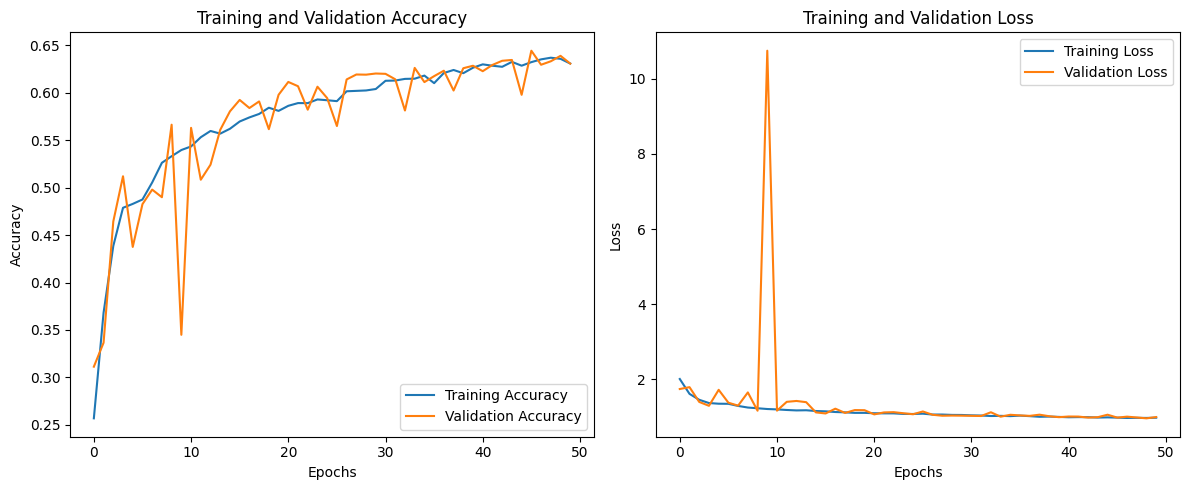

In [54]:
# Panggil fungsi ini setelah model.fit selesai
plot_training_history(history)

In [55]:
import numpy as np

def test_and_visualize_predictions(model, generator, classes):
    images, labels = next(generator)
    predictions = model.predict(images)
    
    plt.figure(figsize=(15, 15))
    
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        
        # --- PERBAIKAN VISUALISASI ---
        # Memastikan data dalam format yang benar untuk imshow
        img = images[i]
        if img.max() > 1.0:
            img = img / 255.0
        plt.imshow(img)
        # -----------------------------

        actual_idx = np.argmax(labels[i])
        pred_idx = np.argmax(predictions[i])
        confidence = predictions[i][pred_idx] * 100
        
        # Mengambil nama kelas (bukan index) untuk judul
        actual_name = classes[actual_idx]
        pred_name = classes[pred_idx]
        
        title = f"Actual: {actual_name}\nPred: {pred_name} ({confidence:.1f}%)"
        title_color = 'green' if actual_idx == pred_idx else 'red'
        
        plt.title(title, color=title_color)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 633ms/step


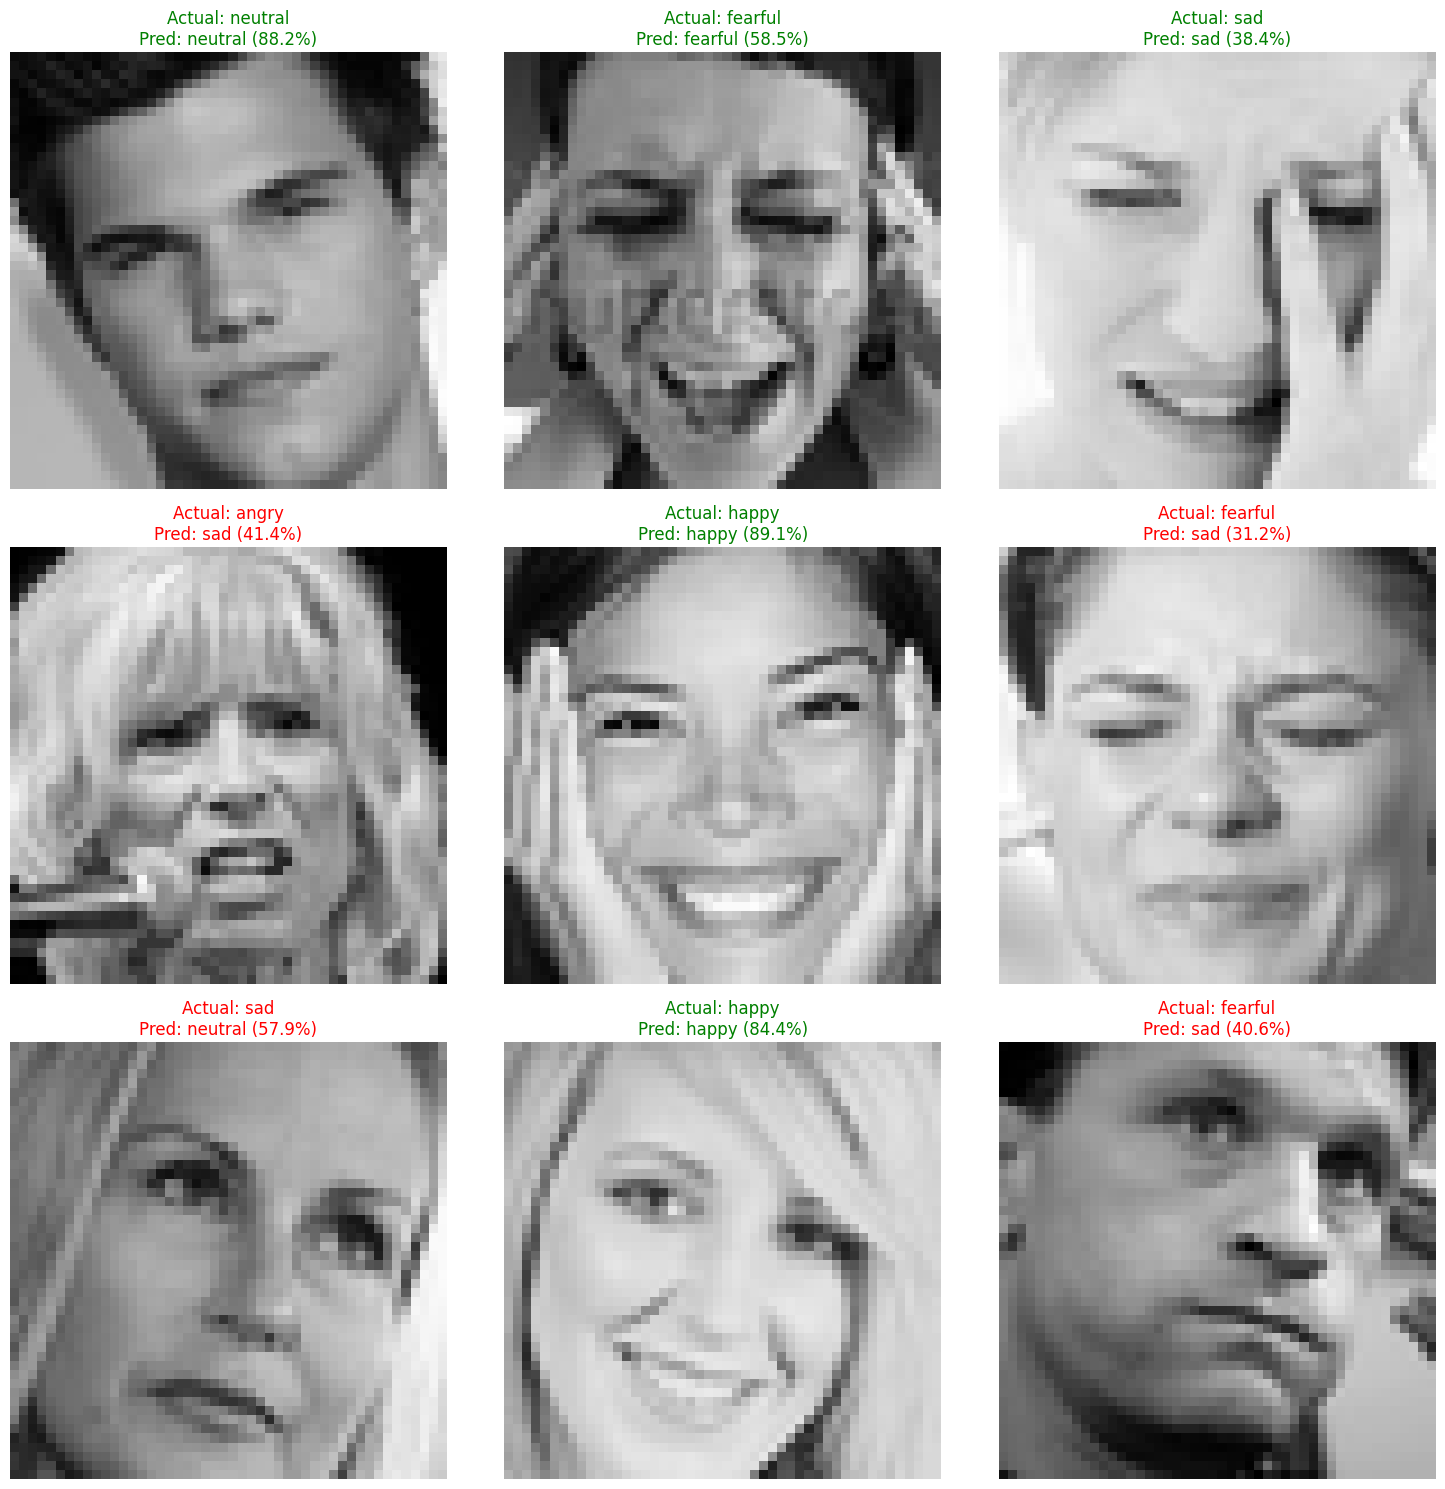

In [56]:
# Panggil fungsi ini untuk uji coba
test_and_visualize_predictions(model, test_generator_shuffled, classes)

In [57]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def show_confusion_matrix(model, generator, classes):
    # Penting: Reset generator agar mulai dari awal
    generator.reset()
    
    # Ambil semua prediksi dari generator (shuffle harus False di sini)
    Y_pred = model.predict(generator)
    y_pred = np.argmax(Y_pred, axis=1)
    
    # Ambil label asli
    y_true = generator.classes
    
    # Hitung Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # Print Classification Report
    print(classification_report(y_true, y_pred, target_names=classes))

225/225 ━━━━━━━━━━━━━━━━━━━━ 51s 226ms/step


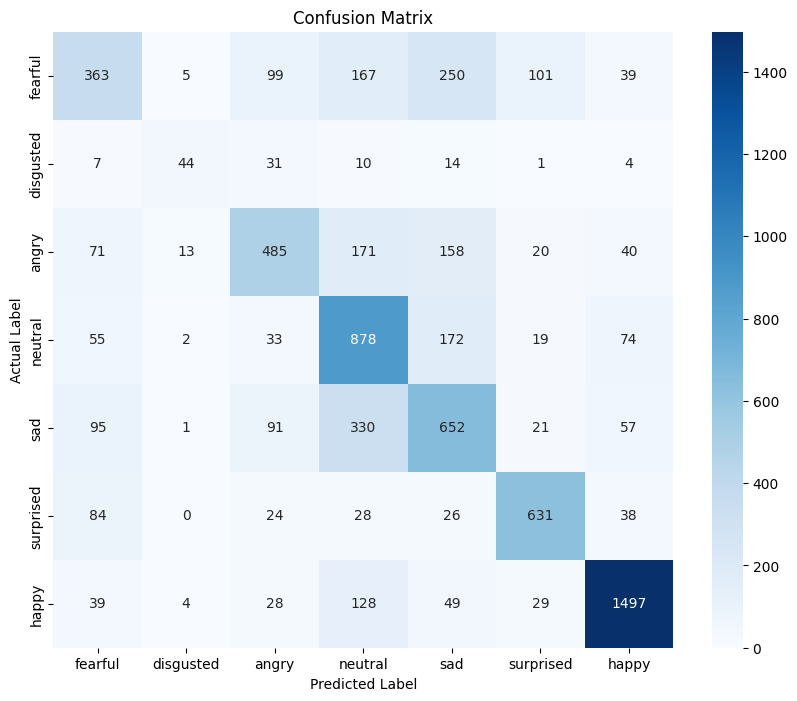

              precision    recall  f1-score   support

     fearful       0.51      0.35      0.42      1024
   disgusted       0.64      0.40      0.49       111
       angry       0.61      0.51      0.55       958
     neutral       0.51      0.71      0.60      1233
         sad       0.49      0.52      0.51      1247
   surprised       0.77      0.76      0.76       831
       happy       0.86      0.84      0.85      1774

    accuracy                           0.63      7178
   macro avg       0.63      0.59      0.60      7178
weighted avg       0.64      0.63      0.63      7178



In [58]:
# Gunakan test_generator (yang shuffle=False) untuk ini
show_confusion_matrix(model, test_generator, classes)

In [59]:
# Langsung uji model yang sudah ada
results = model.evaluate(test_generator)
print(f"Test Loss: {results[0]}, Test Accuracy: {results[1]}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.4955 - loss: 1.2818
Test Loss: 0.9908355474472046, Test Accuracy: 0.6338813304901123


In [60]:
model.save(model_name+'.keras')

In [61]:
model.save(model_name+'.h5')